### Подготовка данных

In [ ]:
import pandas as pd

id = "1nONzIEyXdGGkZJO97Q7Zuv1jyVKSRqhu"
url = f"https://drive.google.com/uc?export=download&id={id}"

df = pd.read_csv(url)

**Описание исходных данных**

Датасет `couriers.csv` — история выходов курьеров на смены. Одна строка = один факт назначения курьера на смену.

**Признаки:**

- `giguser_ext` — идентификатор курьера (исполнителя)
- `shift_date` — дата смены
- `price_per_hour` — ставка курьера за час смены, руб/ч
- `subsidy_per_hour` — субсидия за час смены, руб/ч (доплата, которую агрегатор накидывает сверх ставки)
- `hours` — длительность смены, ч
- `workplace_title` — торговая точка (ТТ), к которой относится смена
- `job_done` — целевая переменная: вышел ли курьер на смену (`1` / `0`)
- `done_shifts_cnt_prev_month` — число закрытых смен курьером за предыдущий месяц

In [ ]:
df.head()

,giguser_ext,shift_date,price_per_hour,subsidy_per_hour,hours,workplace_title,job_done,done_shifts_cnt_prev_month,shift_dayofweek
0,272695536,2025-12-10,103.43,93.86,11.0,66,0,2,2
1,195749882,2025-12-22,103.43,106.75,12.0,62,1,23,0
2,104684637,2025-12-22,140.00,159.10,11.0,45,0,0,0
3,7922992,2025-12-21,140.00,103.50,11.0,16,1,6,6
4,222347908,2025-12-07,140.00,103.50,11.0,12,1,4,6


In [ ]:
df.shape

(1394, 9)

In [ ]:
df["job_done"].value_counts()

,count
job_done,
0,877
1,517


###Baseline

В дальнейшем для обучения ML-модели и оптимизации мы будем рассматривать промежуток спроса по сменам 17-19 декабря. Зафиксируем текущие значения ключевых показателей для дальнейшего сравнения с результатами оптимизации

In [ ]:
base = df[df["shift_date"].between("2025-12-17", "2025-12-19")].copy()

base_fact = base[base["job_done"] == 1].copy()
base_fact["profit"] = base_fact["hours"] * (0.20 * base_fact["price_per_hour"] - base_fact["subsidy_per_hour"])

gmv     = (base_fact["hours"] * base_fact["price_per_hour"]).sum()
subsidy = (base_fact["hours"] * base_fact["subsidy_per_hour"]).sum()

print("AS IS (факт, 17-19 дек):")
print("  закрыто смен:", len(base_fact), "из", len(base))
print("  fill rate:", round(len(base_fact) / len(base), 3))
print("  GMV:", round(gmv))
print("  субсидии:", round(subsidy))
print("  субсидия/GMV:", round(subsidy / gmv, 3))
print("  опер. прибыль:", round(base_fact["profit"].sum()))

AS IS (факт, 17-19 дек):
  закрыто смен: 100 из 249
  fill rate: 0.402
  GMV: 94864
  субсидии: 121507
  субсидия/GMV: 1.281
  опер. прибыль: -102534


### Обучение модели

In [ ]:
data = df.copy()

In [ ]:
X = data.drop(columns=["job_done", "shift_date"])
y = data["job_done"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Логистическая регрессия

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.73      0.69      0.71       176
           1       0.52      0.57      0.55       103

    accuracy                           0.65       279
   macro avg       0.63      0.63      0.63       279
weighted avg       0.66      0.65      0.65       279

ROC-AUC: 0.719991173874669


#### Градиентный бустинг

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=30,
    min_samples_split=50,
    random_state=42
)

In [ ]:
gb_model.fit(X_train, y_train)

train_proba = gb_model.predict_proba(X_train)[:, 1]
test_proba = gb_model.predict_proba(X_test)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, train_proba))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))

y_pred = gb_model.predict(X_test)
y_proba = gb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Train ROC-AUC: 0.8146746883334367
Test ROC-AUC: 0.771954986760812
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       176
           1       0.61      0.57      0.59       103

    accuracy                           0.71       279
   macro avg       0.68      0.68      0.68       279
weighted avg       0.70      0.71      0.70       279

ROC-AUC: 0.771954986760812


**Вывод:** берём модель бустинга.

Рассмотрим также вклад отдельных факторов модели в предсказание целевой переменной. Видим, что наибольшее влияние на вероятность выхода имеет история выхода на смены, размер субсидии не имеет существенного влияния

In [ ]:
import pandas as pd
imp = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp)

done_shifts_cnt_prev_month    0.488010
subsidy_per_hour              0.116168
giguser_ext                   0.112252
hours                         0.107608
workplace_title               0.101667
price_per_hour                0.057028
shift_dayofweek               0.017268
dtype: float64


### Сбор предиктов

In [ ]:
df.head()

,giguser_ext,shift_date,price_per_hour,subsidy_per_hour,hours,workplace_title,job_done,done_shifts_cnt_prev_month,shift_dayofweek
0,272695536,2025-12-10,103.43,93.86,11.0,66,0,2,2
1,195749882,2025-12-22,103.43,106.75,12.0,62,1,23,0
2,104684637,2025-12-22,140.00,159.10,11.0,45,0,0,0
3,7922992,2025-12-21,140.00,103.50,11.0,16,1,6,6
4,222347908,2025-12-07,140.00,103.50,11.0,12,1,4,6


In [ ]:
supply = df.loc[
    df["shift_date"].between("2025-12-10", "2025-12-16"),
    ["giguser_ext", "done_shifts_cnt_prev_month"]
]

In [ ]:
demand = df.loc[
    df["shift_date"].between("2025-12-17", "2025-12-19"),
    df.columns.difference(["giguser_ext", "done_shifts_cnt_prev_month", "job_done", "subsidy_per_hour"])
]

In [ ]:
# на всякий случай фиксируем id смены как индекс строки в demand
demand = demand.reset_index(drop=True).reset_index(names="demand_id")
supply = supply.reset_index(drop=True)

# уровни субсидии
subsidy_levels = pd.DataFrame({
    "subsidy_pct": [0.05, 0.10, 0.15, 0.20, 0.50]
})

# supply × demand
pairs = supply.merge(demand, how="cross")

# supply × demand × subsidy_levels
dataset = pairs.merge(subsidy_levels, how="cross")

# считаем субсидию от price_per_hour
dataset["subsidy_per_hour"] = dataset["price_per_hour"] * dataset["subsidy_pct"]

In [ ]:
dataset.head()

,giguser_ext,done_shifts_cnt_prev_month,demand_id,hours,price_per_hour,shift_date,shift_dayofweek,workplace_title,subsidy_pct,subsidy_per_hour
0,272695536,2,0,11.0,0.0,2025-12-17,2,69,0.05,0.0
1,272695536,2,0,11.0,0.0,2025-12-17,2,69,0.10,0.0
2,272695536,2,0,11.0,0.0,2025-12-17,2,69,0.15,0.0
3,272695536,2,0,11.0,0.0,2025-12-17,2,69,0.20,0.0
4,272695536,2,0,11.0,0.0,2025-12-17,2,69,0.50,0.0


In [ ]:
X_dataset = dataset[X.columns]

dataset["job_done_proba"] = gb_model.predict_proba(X_dataset)[:, 1]

Мы столкнулись с проблемой того, что оптимизатор в дальнейшем слишком долго перебирал датасет из получившихся троек "исполнитель-смена-субсидия", поэтому мы сократили их количество путём оставления топ-60 курьеров на каждую из смен по вероятности выхода и отсекаем вероятности выхода меньше 5%

In [ ]:
# на каждую смену оставляем топ-60 курьеров по вероятности (для каждого уровня субсидии)
N = 60
dataset = (dataset
    .sort_values("job_done_proba", ascending=False)
    .groupby(["demand_id", "subsidy_pct"], group_keys=False)
    .head(N))

# оставляем только вероятность выхода больше 5%
dataset = dataset[dataset["job_done_proba"] >= 0.05]

print("офферов осталось:", len(dataset),
      "| курьеров в пуле:", dataset["giguser_ext"].nunique())

офферов осталось: 74700 | курьеров в пуле: 65


<Axes: >

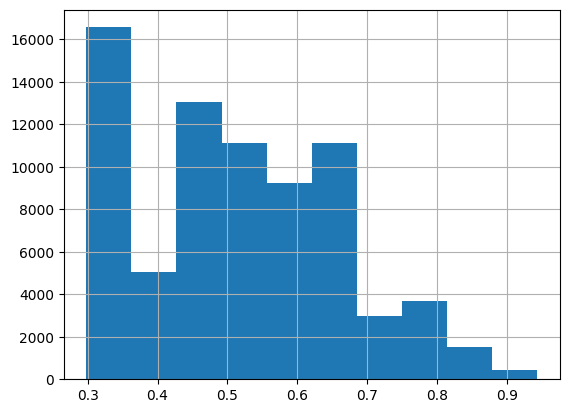

In [ ]:
dataset['job_done_proba'].hist()

In [ ]:
dataset.groupby("subsidy_pct")["job_done_proba"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
subsidy_pct,,,,
0.05,0.495163,0.495037,0.298009,0.846630
0.10,0.494696,0.492232,0.298009,0.840808
0.15,0.491314,0.481867,0.298009,0.838288
0.20,0.491314,0.481867,0.298009,0.838288
0.50,0.591645,0.634432,0.298009,0.943428


In [ ]:
import numpy as np

dataset = dataset.drop_duplicates(
    subset=["giguser_ext", "demand_id", "subsidy_pct"]
).reset_index(drop=True)

dataset["offer_id"] = np.arange(len(dataset))
dataset["day_id"]   = dataset["shift_date"].astype(str).str[:10]

print("офферов после дедупа:", len(dataset))

офферов после дедупа: 27022


In [ ]:
dataset

,giguser_ext,done_shifts_cnt_prev_month,demand_id,hours,price_per_hour,shift_date,shift_dayofweek,workplace_title,subsidy_pct,subsidy_per_hour,job_done_proba,offer_id,day_id
0,1017182,14,247,6.5,103.43,2025-12-19,4,68,0.50,51.715,0.943428,0,2025-12-19
1,1017182,14,210,8.0,103.43,2025-12-19,4,55,0.50,51.715,0.938041,1,2025-12-19
2,1017182,15,145,8.0,103.43,2025-12-19,4,55,0.50,51.715,0.938041,2,2025-12-19
3,1017182,15,62,8.0,103.43,2025-12-19,4,55,0.50,51.715,0.938041,3,2025-12-19
4,1017182,14,110,9.0,103.43,2025-12-19,4,65,0.50,51.715,0.935980,4,2025-12-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27017,354269810,3,125,11.0,0.00,2025-12-18,3,9,0.05,0.000,0.298009,27017,2025-12-18
27018,340628889,3,139,11.0,0.00,2025-12-17,2,9,0.05,0.000,0.298009,27018,2025-12-17
27019,354269810,3,152,11.0,0.00,2025-12-18,3,9,0.20,0.000,0.298009,27019,2025-12-18
27020,354269810,3,152,11.0,0.00,2025-12-18,3,9,0.50,0.000,0.298009,27020,2025-12-18


### Оптимизация в AMPL

#### Обозначения для множеств, параметров и переменных задачи

**Множества**
 - $K$ — офферы (тройки «исполнитель — смена — размер субсидии»)
 - $E$ — исполнители
 - $S$ — смены (потребность, спрос)
 - $D$ — дни планирования

Необходимые **параметры-связки** (для каждого оффера $k$):

 - $e_k$ — исполнитель оффера
 - $s_k$ — смена оффера
 - $day_k$ — день смены

Необходимые **числовые параметры оффера** $k$:

 - $p_k$ — вероятность закрытия смены (прогноз ML-модели)
 - $h_k$ — длительность смены, ч
 - $r_k$ — ставка исполнителя, руб/ч
 - $sub_k$ — наша субсидия, руб/ч

**Скалярные бизнес-параметры**:

 - $tr = 0{,}20$ — take rate агрегатора
 - $fr = 0{,}60$ — минимальный ожидаемый fill rate
 - $sub\_GMV\_max = 0{,}15$ — лимит доли субсидии в GMV

Необходимая **переменная**:

 - $x_k \in \{0,1\}$ — назначаем оффер $k$ или нет

#### Математическая постановка задачи

#### Ограничения

1. На одну смену назначается не более одной тройки (исполнитель + cмена + уровень субсидии)

$$
\sum_{k \,:\, s_k = j} x_k \le 1, \quad \forall j \in S
$$

2. Один исполнитель закрывает не более одной смены в день

$$
\sum_{k \,:\, e_k = i,\ day_k = d} x_k \le 1, \quad \forall i \in E,\ \forall d \in D
$$

3. Ожидаемый fill rate не ниже заданного порога (ожидаемое число закрытых смен $\ge fr$ от общей потребности)

$$
\sum_{k \in K} x_k \, p_k \;\ge\; fr \cdot S
$$

4. Доля субсидии в обороте не превышает лимита (ожидаемая субсидия $\le sub\_GMV\_max$ от ожидаемого GMV)

$$
\sum_{k \in K} x_k \, p_k \, sub_k \, h_k \;\le\; sub\_GMV\_max \sum_{k \in K} x_k \, p_k \, r_k \, h_k
$$

####Целевая функция

Целью является максимизация операционной прибыли. На каждой закрытой смене прибыль = (GMV $\cdot$ take rate) - выплаченная субсидия

Оборот смены (GMV) равен $r_k$ (ставка исполнителя) $\cdot$ $h_k$ (длительность смены), комиссия — $tr$ (наш take rate) $\cdot$ $r_k \cdot h_k$, субсидия — $sub_k$ (размер субсидии)$\cdot$ $h_k$. И выручка, и субсидия выплачиваются только при закрытии смены, поэтому всё умножается на вероятность $p_k$:

$$
\sum_{k \in K} x_k \, p_k \ h_k \,\big(tr\ \cdot r_k - sub_k\big) \;\to\; \max
$$


###Модель AMPL

In [ ]:
%pip install -q amplpy

In [ ]:
# Интеграция с Google Colab и Kaggle Notebook
from amplpy import AMPL, ampl_notebook

In [ ]:
# Создание объекта для AMPL и установка решателя
ampl = ampl_notebook(
    modules=["highs", "plugins"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


In [ ]:
%%ampl_eval
reset;

# ----- МНОЖЕСТВА -----
set OFFERS;                   # K — тройки исполнитель—смена—субсидия
set EXE;                      # E — исполнители
set SHIFTS;                   # S — смены (спрос)
set DAYS;                     # D — дни

# ----- ПАРАМЕТРЫ-СВЯЗКИ -----
param exe{OFFERS}   symbolic in EXE;     # e_k
param shift{OFFERS} symbolic in SHIFTS;  # s_k
param day{OFFERS}   symbolic in DAYS;    # day_k

# ----- ЧИСЛОВЫЕ ПАРАМЕТРЫ ОФФЕРА -----
param prob{OFFERS} >= 0, <= 1;   # p_k
param hours{OFFERS} >= 0;        # h_k
param rate{OFFERS}  >= 0;        # r_k
param sub{OFFERS}   >= 0;        # sub_k

# ----- СКАЛЯРНЫЕ БИЗНЕС-ПАРАМЕТРЫ -----
param tr >= 0;                   # take rate
param fr >= 0, <= 1;             # мин. fill rate
param sub_gmv_max >= 0;          # лимит субсидия/GMV

# ----- ПЕРЕМЕННАЯ -----
var x{OFFERS} binary;            # x_k

# ----- ЦЕЛЕВАЯ -----
maximize OperatingProfit:
    sum{k in OFFERS} x[k] * prob[k] * hours[k] * (tr * rate[k] - sub[k]);

# ----- ОГРАНИЧЕНИЯ -----
subject to OneOfferPerShift{j in SHIFTS}:
    sum{k in OFFERS: shift[k] = j} x[k] <= 1; #

subject to OneShiftPerExePerDay{i in EXE, d in DAYS}:
    sum{k in OFFERS: exe[k] = i and day[k] = d} x[k] <= 1; #

subject to FillRate:
    sum{k in OFFERS} x[k] * prob[k] >= fr * card(SHIFTS); #

subject to SubsidyShare:
    sum{k in OFFERS} x[k] * prob[k] * sub[k] * hours[k] <= sub_gmv_max * sum{k in OFFERS} x[k] * prob[k] * rate[k] * hours[k]; #

In [ ]:
print("офферов:", len(dataset),
      "| смен:", dataset["demand_id"].nunique(),
      "| курьеров:", dataset["giguser_ext"].nunique())

офферов: 27022 | смен: 249 | курьеров: 65


In [ ]:
ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.34
ampl.param["sub_gmv_max"] = 0.15

In [ ]:
%%ampl_eval

option solver highs;
solve;

HiGHS 1.14.0:   Warning code 1 for call loader().Highs_addRows(lp(), acc_constraints_.lb.size(), acc_constraints_.lb.data(), acc_constraints_.ub.data(), acc_constraints_.coeffs.size(), acc_constraints_.starts.data(), acc_constraints_.indices.data(), acc_constraints_.coeffs.data())
HiGHS 1.14.0: optimal solution; objective 7621.032232
19628 simplex iterations
1070 branching nodes
absmipgap=0.553187, relmipgap=7.25869e-05


In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

{'Назначено троек': 153,
 'Всего смен (спрос)': 249,
 'Ожид. fill rate': np.float64(0.34),
 'Ожид. GMV': np.float64(104881.0),
 'Субсидия/GMV': np.float64(0.127),
 'Ожид. опер. прибыль': np.float64(7621.0),
 'макс на смену': 1,
 'макс на курьера в день': 1}

In [ ]:
# AMPL вернул x по каждому офферу; берём те, где x = 1 (выбран)
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]

selected = x_values.loc[x_values["x"] > 0.5, "offer_id"].astype(int)

# оставляем в таблице только выбранные тройки = это и есть план назначений
solution = dataset[dataset["offer_id"].isin(selected)].copy()

In [ ]:
solution

In [ ]:
gmv_tobe     = (solution["job_done_proba"] * solution["hours"] * solution["price_per_hour"]).sum()
subsidy_tobe = (solution["job_done_proba"] * solution["hours"] * solution["subsidy_per_hour"]).sum()
profit_tobe  = (solution["job_done_proba"] * solution["hours"] *
                (0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"])).sum()

total_shifts = dataset["demand_id"].nunique()

print("TO BE (оптимум, 17-19 дек):")
print("  закрыто смен (ожид.):", round(solution["job_done_proba"].sum(), 1), "из", total_shifts)
print("  fill rate:", round(solution["job_done_proba"].sum() / total_shifts, 3))
print("  GMV:", round(gmv_tobe))
print("  субсидии:", round(subsidy_tobe))
print("  субсидия/GMV:", round(subsidy_tobe / gmv_tobe, 3))
print("  опер. прибыль:", round(profit_tobe))

In [ ]:
print("теоретический максимум fill rate:",
      round(dataset.groupby("demand_id")["job_done_proba"].max().mean(), 3))

###Многокритериальный анализ чувствительности

смотрим на компромисс между филл рейом и ожидаемой прибылью. уменьшаем филл рейт и смотрим как меняется прибыль и саб гмв

In [ ]:
#филлрейт 0.0

ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.0
ampl.param["sub_gmv_max"] = 0.15



In [ ]:
%%ampl_eval

option solver highs;
solve;

In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

In [ ]:
#филлрейт 0.28

ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.28
ampl.param["sub_gmv_max"] = 0.15



In [ ]:
%%ampl_eval

option solver highs;
solve;

In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

In [ ]:
#филлрейт 0.3

ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.3
ampl.param["sub_gmv_max"] = 0.15



In [ ]:
%%ampl_eval

option solver highs;
solve;

In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

In [ ]:
#филлрейт 0.32

ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.32
ampl.param["sub_gmv_max"] = 0.15



In [ ]:
%%ampl_eval

option solver highs;
solve;

In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

In [ ]:
#филлрейт 0.33

ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.33
ampl.param["sub_gmv_max"] = 0.15



In [ ]:
%%ampl_eval

option solver highs;
solve;

In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

In [ ]:
#филлрейт 0.31

ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.31
ampl.param["sub_gmv_max"] = 0.15



In [ ]:
%%ampl_eval

option solver highs;
solve;

In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary



```
# This is formatted as code
```

###альтернативный сценарий

мы хотим попробовать заменить ограничение по тому, что на одного курьера приходится максимум 1 смена в день на то, чтобы сделать ограничение на 12 часов в день на одного курьера. то есть он сможет взять несколько смен, но чтобы суммарно они были менее 12 часов

тогда ожидаемо мы сможем увеличить филл рейт

важное допущение:
у нас нет данных по началу и окончанию каждой смены, поэтому они потенциально могут накладываться друг на друга, что в реальной жизни помешает курьеру выполнить несколько - он физически сможет вязть только одну. мы примем это допущение и ради эксперимента посмотрим на результат

In [ ]:
%pip install -q amplpy

In [ ]:
# Интеграция с Google Colab и Kaggle Notebook
from amplpy import AMPL, ampl_notebook

In [ ]:
# Создание объекта для AMPL и установка решателя
ampl = ampl_notebook(
    modules=["highs", "plugins"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


In [ ]:
%%ampl_eval
reset;

# ----- МНОЖЕСТВА -----
set OFFERS;                   # K — тройки исполнитель—смена—субсидия
set EXE;                      # E — исполнители
set SHIFTS;                   # S — смены (спрос)
set DAYS;                     # D — дни

# ----- ПАРАМЕТРЫ-СВЯЗКИ -----
param exe{OFFERS}   symbolic in EXE;     # e_k
param shift{OFFERS} symbolic in SHIFTS;  # s_k
param day{OFFERS}   symbolic in DAYS;    # day_k

# ----- ЧИСЛОВЫЕ ПАРАМЕТРЫ ОФФЕРА -----
param prob{OFFERS} >= 0, <= 1;   # p_k
param hours{OFFERS} >= 0;        # h_k
param rate{OFFERS}  >= 0;        # r_k
param sub{OFFERS}   >= 0;        # sub_k

# ----- СКАЛЯРНЫЕ БИЗНЕС-ПАРАМЕТРЫ -----
param tr >= 0;                   # take rate
param fr <= 0.5;             # мин. fill rate
param sub_gmv_max >= 0;          # лимит субсидия/GMV
param max_hours_per_day >= 0;          # в секции param

# ----- ПЕРЕМЕННАЯ -----
var x{OFFERS} binary;            # x_k

# ----- ЦЕЛЕВАЯ -----
maximize OperatingProfit:
    sum{k in OFFERS} x[k] * prob[k] * hours[k] * (tr * rate[k] - sub[k]);

# ----- ОГРАНИЧЕНИЯ -----
subject to OneOfferPerShift{j in SHIFTS}:
    sum{k in OFFERS: shift[k] = j} x[k] <= 1; #

subject to MaxHoursPerExePerDay{i in EXE, d in DAYS}:
    sum{k in OFFERS: exe[k] = i and day[k] = d} x[k] * hours[k] <= 12; #

subject to FillRate:
    sum{k in OFFERS} x[k] * prob[k] >= fr * card(SHIFTS); #

subject to SubsidyShare:
    sum{k in OFFERS} x[k] * prob[k] * sub[k] * hours[k] <= sub_gmv_max * sum{k in OFFERS} x[k] * prob[k] * rate[k] * hours[k]; #

In [ ]:
print("офферов:", len(dataset),
      "| смен:", dataset["demand_id"].nunique(),
      "| курьеров:", dataset["giguser_ext"].nunique())

офферов: 27022 | смен: 249 | курьеров: 65


In [ ]:
ampl.set["OFFERS"] = dataset["offer_id"].tolist()
ampl.set["EXE"]    = dataset["giguser_ext"].unique().tolist()
ampl.set["SHIFTS"] = dataset["demand_id"].unique().tolist()
ampl.set["DAYS"]   = dataset["shift_date"].astype(str).str[:10].unique().tolist()

ampl.param["exe"]   = dict(zip(dataset["offer_id"], dataset["giguser_ext"]))
ampl.param["shift"] = dict(zip(dataset["offer_id"], dataset["demand_id"]))
ampl.param["day"]   = dict(zip(dataset["offer_id"], dataset["shift_date"].astype(str).str[:10]))

ampl.param["prob"]  = dict(zip(dataset["offer_id"], dataset["job_done_proba"]))
ampl.param["hours"] = dict(zip(dataset["offer_id"], dataset["hours"]))
ampl.param["rate"]  = dict(zip(dataset["offer_id"], dataset["price_per_hour"]))
ampl.param["sub"]   = dict(zip(dataset["offer_id"], dataset["subsidy_per_hour"]))
ampl.param["max_hours_per_day"] = 12

ampl.param["tr"]          = 0.20
ampl.param["fr"]          = 0.34
ampl.param["sub_gmv_max"] = 5

In [ ]:
%%ampl_eval

option solver highs;
solve;

HiGHS 1.14.0: HiGHS 1.14.0: optimal solution; objective 7621.342749
25475 simplex iterations
1134 branching nodes
absmipgap=0.653638, relmipgap=8.57641e-05


In [ ]:
# 2. забираем решение из AMPL
x_values = ampl.get_variable("x").get_values().to_pandas().reset_index()
x_values.columns = ["offer_id", "x"]
x_values["offer_id"] = x_values["offer_id"].astype(int)
x_values["x"] = x_values["x"].round().astype(int)

# 3. собираем solution через merge
chosen = x_values.loc[x_values["x"] == 1, ["offer_id"]]
solution = dataset.merge(chosen, on="offer_id", how="inner").copy()

# 4. метрики
solution["exp_closed"]  = solution["job_done_proba"]
solution["exp_gmv"]     = solution["job_done_proba"] * solution["price_per_hour"] * solution["hours"]
solution["exp_subsidy"] = solution["job_done_proba"] * solution["subsidy_per_hour"] * solution["hours"]
solution["exp_profit"]  = solution["job_done_proba"] * solution["hours"] * (
    0.20 * solution["price_per_hour"] - solution["subsidy_per_hour"]
)

total_shifts = dataset["demand_id"].nunique()

summary = {
    "Назначено троек":     len(solution),
    "Всего смен (спрос)":  total_shifts,
    "Ожид. fill rate":     round(solution["exp_closed"].sum() / total_shifts, 3),
    "Ожид. GMV":           round(solution["exp_gmv"].sum(), 0),
    "Субсидия/GMV":        round(solution["exp_subsidy"].sum() / solution["exp_gmv"].sum(), 3),
    "Ожид. опер. прибыль": round(solution["exp_profit"].sum(), 0),
    "макс на смену":            solution.groupby("demand_id").size().max(),
    "макс на курьера в день":   solution.groupby(["giguser_ext","day_id"]).size().max(),
}
summary

{'Назначено троек': 153,
 'Всего смен (спрос)': 249,
 'Ожид. fill rate': np.float64(0.34),
 'Ожид. GMV': np.float64(104880.0),
 'Субсидия/GMV': np.float64(0.127),
 'Ожид. опер. прибыль': np.float64(7621.0),
 'макс на смену': 1,
 'макс на курьера в день': 2}

In [ ]:
chk = solution.groupby(["giguser_ext", "day_id"]).agg(
    смен=("hours","size"), часов=("hours","sum"))
print("макс смен на курьера в день:", chk["смен"].max(), "(теперь может быть >1)")
print("макс часов на курьера в день:", chk["часов"].max(), "(<= 12)")

макс смен на курьера в день: 2 (теперь может быть >1)
макс часов на курьера в день: 12.0 (<= 12)


In [ ]:
print("потолок fill rate по вероятностям:",
      round(dataset.groupby("demand_id")["job_done_proba"].max().mean(), 3))

потолок fill rate по вероятностям: 0.717
